<a href="https://colab.research.google.com/github/Nipun-Pasindu/Statistical-Learning-E23210/blob/main/Assignments/Assignment_06_GPR_and_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.metrics import mean_squared_error, r2_score

path = kagglehub.dataset_download("ujjwalchowdhury/energy-efficiency-data-set")
df = pd.read_csv(path + "/ENB2012_data.csv")

X = df.iloc[:, 0:8]
y1 = df["Y1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y1, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)

gpr_y1 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)

gpr_y1.fit(X_train_scaled, y_train)
y1_pred, sigma1 = gpr_y1.predict(X_test_scaled, return_std=True)

rmse_y1 = np.sqrt(mean_squared_error(y_test, y1_pred))
r2_y1 = r2_score(y_test, y1_pred)

print(f"Heating Load RMSE = {rmse_y1:.4f}")
print(f"Heating Load R² Score = {r2_y1:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y1_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("GPR Prediction - Heating Load (Y1)")
plt.legend()
plt.grid(True)
plt.show()

y2 = df["Y2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y2, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gpr_y2 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)

gpr_y2.fit(X_train_scaled, y_train)
y2_pred, sigma2 = gpr_y2.predict(X_test_scaled, return_std=True)

rmse_y2 = np.sqrt(mean_squared_error(y_test, y2_pred))
r2_y2 = r2_score(y_test, y2_pred)

print(f"Cooling Load RMSE = {rmse_y2:.4f}")
print(f"Cooling Load R² Score = {r2_y2:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y2_pred, color='green', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("GPR Prediction - Cooling Load (Y2)")
plt.legend()
plt.grid(True)
plt.show()

Using Colab cache for faster access to the 'energy-efficiency-data-set' dataset.


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/energy-efficiency-data-set/ENB2012_data.csv'

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset

--- Dataset Overview ---
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       828.108509   
3     32.195231   

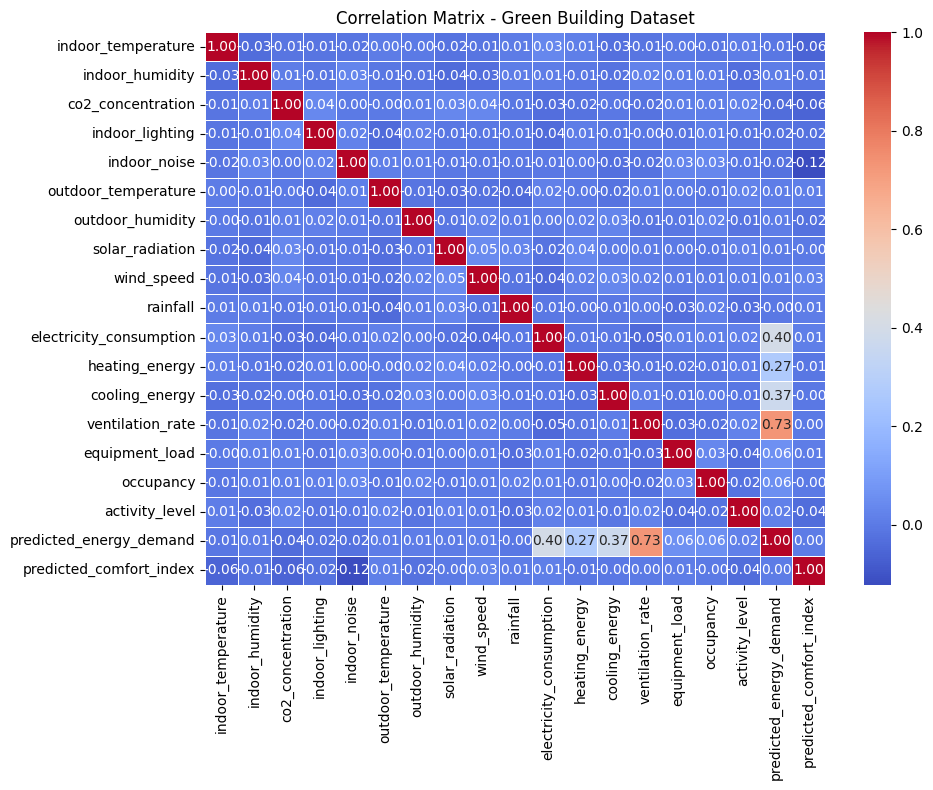


--- Correlation with predicted_energy_demand ---
predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64

--- Linear Regression Performance Metrics ---
Linear Regression RMSE = 9.6135
Linear Regression R² Score = 0.0100


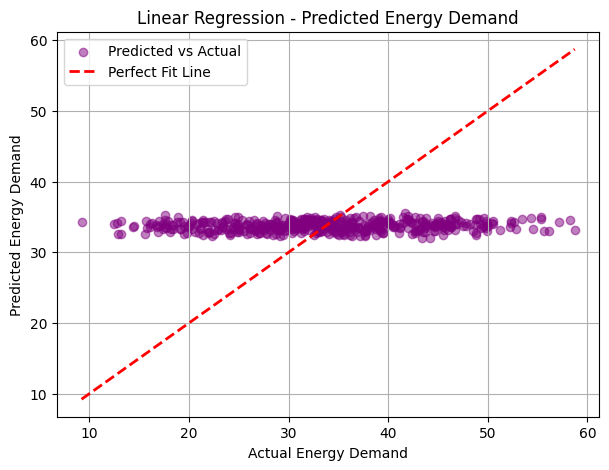

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Download and Load the Green Building Dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Read the CSV file into df2
df2 = pd.read_csv(path + "/green_building_dataset.csv")
df_green = df2

# Display initial data info
print("\n--- Dataset Overview ---")
print(df_green.head())
print("\nDataset Columns:", df_green.columns)

# 2. Correlation Analysis (Justification for Feature Selection)
# We compute the correlation matrix to see how features relate to 'predicted_energy_demand'
corr = df_green.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Green Building Dataset")
plt.tight_layout()
plt.show()

# Print correlations specific to the target variable
print("\n--- Correlation with predicted_energy_demand ---")
print(corr["predicted_energy_demand"].sort_values(ascending=False))

# 3. Feature Selection
# Note: We select meaningful environmental and structural inputs.
# We purposely avoid 'heating_energy' or 'cooling_energy' to prevent data leakage,
# since they are direct sub-components of the total energy demand.
selected_features = [
    'indoor_temperature',
    'outdoor_temperature',
    'solar_radiation',
    'occupancy',
    'equipment_load'
]

X_green = df_green[selected_features]
y_green = df_green['predicted_energy_demand']

# 4. Split the Data
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_green, y_green, test_size=0.2, random_state=42
)

# 5. Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_g, y_train_g)

# 6. Predict on Test Split
y_pred_g = lr_model.predict(X_test_g)

# 7. Evaluate Model Performance
rmse_g = np.sqrt(mean_squared_error(y_test_g, y_pred_g))
r2_g = r2_score(y_test_g, y_pred_g)

print("\n--- Linear Regression Performance Metrics ---")
print(f"Linear Regression RMSE = {rmse_g:.4f}")
print(f"Linear Regression R² Score = {r2_g:.4f}")

# 8. Plot Linear Regression Results
plt.figure(figsize=(7, 5))
plt.scatter(y_test_g, y_pred_g, color='purple', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_g.min(), y_test_g.max()], [y_test_g.min(), y_test_g.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Linear Regression - Predicted Energy Demand")
plt.legend()
plt.grid(True)
plt.show()